# Data Preprocessing — Full Practice

This notebook uses one **60,000-row classification dataset** containing common preprocessing problems.

The teaching flow is:

**Import → Inspect → Clean → Explore → Define X/y → Split → Learn preprocessing from Train → Model-ready data**

The main idea is simple:

**See the evidence first, then choose the preprocessing method.**

There is **no machine-learning model** in this notebook.

## Problems inside the dataset

The raw data intentionally contains:

- exact duplicate rows
- numerical values stored as text
- invalid domain values
- missing numerical and categorical values
- mixed datetime formats
- a mostly-missing column
- inconsistent category spelling/case
- skewed numerical columns
- IQR and Z-score outliers
- features with very different scales
- an imbalanced binary target

`Economic_Index` is also used to demonstrate `ffill()` / `bfill()` for ordered data.

> `ffill` and `bfill` handle **missing ordered values**. They do not handle class imbalance.

## Dataset Column Description

This dataset contains customer information used to study customer behavior and predict customer churn.

| Column | Description |
|---|---|
| **Customer_ID** | A unique identification number assigned to each customer. |
| **Age** | The age of the customer in years. |
| **Monthly_Income** | The customer's estimated monthly income. |
| **Credit_Score** | A numerical score representing the customer's creditworthiness. |
| **City** | The city where the customer lives. |
| **Gender** | The gender of the customer. |
| **Contract_Type** | The type of service contract selected by the customer, such as monthly, one-year, or two-year. |
| **Satisfaction_Level** | The customer's level of satisfaction with the service, such as Low, Medium, or High. |
| **Tenure_Months** | The number of months the customer has been using the company's service. |
| **Monthly_Usage_GB** | The amount of data used by the customer per month, measured in gigabytes (GB). |
| **Avg_Session_Minutes** | The average duration of a customer's service session, measured in minutes. |
| **Support_Calls** | The number of times the customer contacted customer support. |
| **Application_Date** | The date when the customer registered or started using the service. |
| **Economic_Index** | A numerical indicator representing the economic conditions associated with the customer at the time of registration. |
| **Promo_Code** | The promotional or discount code used by the customer, if any. |
| **Churned** | The target variable indicating whether the customer left the company. `0` means the customer stayed, while `1` means the customer churned. |

In [1]:
pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 3.7 MB/s  0:00:02m0:00:0100:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 3.4 MB/s  0:00:06 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None) # do not hide any columns every time we run it



# 1. Import the raw dataset

Read the file first. Do not clean anything yet.

In [4]:
df = pd.read_csv(r"/Users/youssefemad/RouteCycle11-Material/Session_8_Preprocessing/customer_churn_preprocessing_problems_60k.csv")
df.head()

,Customer_ID,Age,Monthly_Income,Credit_Score,City,Gender,Contract_Type,Satisfaction_Level,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Application_Date,Economic_Index,Promo_Code,Churned
0,112629,49,6303.75,733.1,NaN,Male,One year,Medium,21.0,86.18,31.28,3.0,2024-04-15,106.50,NaN,0
1,137731,18,11778.13,647.9,ALEXANDRIA,female,One year,High,9.0,19.87,66.82,0.0,Jun 14 2024,105.25,NaN,0
2,139992,60,11371.69,608.4,Giza,Female,Month-to-month,High,42.0,23.92,91.58,2.0,Jan 22 2024,102.88,NaN,0
3,108526,35,21656.24,799.2,Giza,Female,Month-to-month,High,64.0,56.71,41.96,2.0,NaN,101.29,NaN,0
4,108280,44,11929.67,480.5,Alexandria,Female,One year,Medium,12.0,24.32,47.00,1.0,12/30/2025,102.30,VIP,0


# 2. Initial inspection — before cleaning

Before changing the data, inspect what actually arrived.

We check:

- first rows
- shape
- data types
- numerical summary
- object/categorical columns
- missing values
- duplicates
- target distribution

This step helps us **discover the problems that cleaning must solve**.

### 2.1 First rows

In [5]:
df.head()

,Customer_ID,Age,Monthly_Income,Credit_Score,City,Gender,Contract_Type,Satisfaction_Level,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Application_Date,Economic_Index,Promo_Code,Churned
0,112629,49,6303.75,733.1,NaN,Male,One year,Medium,21.0,86.18,31.28,3.0,2024-04-15,106.50,NaN,0
1,137731,18,11778.13,647.9,ALEXANDRIA,female,One year,High,9.0,19.87,66.82,0.0,Jun 14 2024,105.25,NaN,0
2,139992,60,11371.69,608.4,Giza,Female,Month-to-month,High,42.0,23.92,91.58,2.0,Jan 22 2024,102.88,NaN,0
3,108526,35,21656.24,799.2,Giza,Female,Month-to-month,High,64.0,56.71,41.96,2.0,NaN,101.29,NaN,0
4,108280,44,11929.67,480.5,Alexandria,Female,One year,Medium,12.0,24.32,47.00,1.0,12/30/2025,102.30,VIP,0


### 2.2 Shape

In [4]:
df.shape

(60000, 16)

### 2.3 Data types with `info()`

`info()` is useful here because a column that should be numerical may appear as `object`.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          60000 non-null  int64  
 1   Age                  58521 non-null  str    
 2   Monthly_Income       57908 non-null  float64
 3   Credit_Score         58806 non-null  float64
 4   City                 58800 non-null  str    
 5   Gender               59281 non-null  str    
 6   Contract_Type        58918 non-null  str    
 7   Satisfaction_Level   58803 non-null  str    
 8   Tenure_Months        59102 non-null  float64
 9   Monthly_Usage_GB     58804 non-null  float64
 10  Avg_Session_Minutes  59098 non-null  float64
 11  Support_Calls        59401 non-null  float64
 12  Application_Date     58931 non-null  str    
 13  Economic_Index       58325 non-null  float64
 14  Promo_Code           5996 non-null   str    
 15  Churned              60000 non-null  int64  
dt

### 2.4 Numerical summary with `describe()`

This shows the numerical columns that Pandas currently recognizes as numeric.

In [6]:
df.describe()

,Customer_ID,Monthly_Income,Credit_Score,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Economic_Index,Churned
count,60000.000000,57908.000000,58806.000000,59102.000000,58804.000000,59098.000000,59401.000000,58325.000000,60000.000000
mean,129870.806500,15200.117263,655.109298,30.569828,53.181546,47.480746,2.207656,104.481224,0.084567
std,17247.466941,14114.025532,76.372733,18.041173,39.632115,16.074360,1.494984,1.878070,0.278238
min,100001.000000,2500.000000,120.000000,1.000000,2.000000,5.000000,0.000000,98.830000,0.000000
25%,114929.750000,7715.220000,604.725000,17.000000,26.330000,38.390000,1.000000,103.050000,0.000000
50%,129865.500000,11937.890000,655.300000,27.000000,44.820000,47.080000,2.000000,104.510000,0.000000
75%,144804.250000,18658.387500,706.000000,42.000000,70.610000,55.770000,3.000000,105.940000,0.000000
max,159750.000000,815730.181611,980.000000,72.000000,1278.219002,299.795362,10.000000,110.400000,1.000000


### 2.5 Inspect object columns with `select_dtypes()`

Use `select_dtypes(include="object")` to identify the columns currently stored as objects.

This also helps us notice columns such as `Age` that may be stored as text because of bad values.

In [8]:
object_data = df.select_dtypes(include="object")

print("Object columns:")
print(object_data.columns.tolist())

object_data.head()


Object columns:
['Age', 'City', 'Gender', 'Contract_Type', 'Satisfaction_Level', 'Application_Date', 'Promo_Code']


,Age,City,Gender,Contract_Type,Satisfaction_Level,Application_Date,Promo_Code
0,49,NaN,Male,One year,Medium,2024-04-15,NaN
1,18,ALEXANDRIA,female,One year,High,Jun 14 2024,NaN
2,60,Giza,Female,Month-to-month,High,Jan 22 2024,NaN
3,35,Giza,Female,Month-to-month,High,NaN,NaN
4,44,Alexandria,Female,One year,Medium,12/30/2025,VIP


### 2.6 Missing-value overview

In [8]:
missing_raw = df.isna().sum().to_frame("Missing_Count")
missing_raw["Missing_%"] = (df.isna().mean() * 100).round(2)

missing_raw.sort_values("Missing_%", ascending=False)


,Missing_Count,Missing_%
Promo_Code,54004,90.01
Monthly_Income,2092,3.49
Economic_Index,1675,2.79
Age,1479,2.46
City,1200,2.00
Satisfaction_Level,1197,2.00
Credit_Score,1194,1.99
Monthly_Usage_GB,1196,1.99
Contract_Type,1082,1.80
Application_Date,1069,1.78


### 2.7 Exact duplicates

In [9]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 250


### 2.8 Raw target distribution

In [10]:
(df['Churned'].value_counts(normalize=True)*100).round(2)

Churned
0    91.54
1     8.46
Name: proportion, dtype: float64

In [12]:
print("Count:")
print(df["Churned"].value_counts())

print("\nPercent:")
print((df["Churned"].value_counts(normalize=True) * 100).round(2))


Count:
Churned
0    54926
1     5074
Name: count, dtype: int64

Percent:
Churned
0    91.54
1     8.46
Name: proportion, dtype: float64


### What did the initial inspection tell us?

We now know what needs cleaning before deeper EDA:

- `Age` is not stored correctly as a numerical column.
- categorical text contains inconsistent forms.
- the date column needs datetime conversion.
- duplicate rows exist.
- several columns contain missing values.
- `Promo_Code` has very high missingness.
- the target is imbalanced.

Now we can clean the known data-quality problems.

# 3. Basic cleaning before EDA

These are **deterministic data-quality rules**.

They do not learn a mean, median, IQR boundary, category vocabulary, or scale from the full dataset.

### 3.1 Remove confirmed exact duplicates

We remove only exact repeated rows.

Similar records are not automatically duplicates.

In [13]:
len(df)

60000

In [14]:
print("Before:", len(df))

df = df.drop_duplicates().reset_index(drop=True)

print("After :", len(df))


Before: 60000
After : 59750


In [15]:
len(df)

59750

### 3.2 Fix numeric text and impossible domain values

`Age` contains text such as `unknown`, so it must first become numeric.

For this teaching dataset:

- valid age: 18–90
- valid credit score: 300–850

Impossible values are changed to missing so they can be handled later.

In [16]:
df["Age"].min()

' 18 '

In [13]:
df["Age"]= pd.to_numeric(df["Age"],errors="coerce")

In [14]:
df.describe()

,Customer_ID,Age,Monthly_Income,Credit_Score,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Economic_Index,Churned
count,60000.000000,57801.000000,57908.000000,58806.000000,59102.000000,58804.000000,59098.000000,59401.000000,58325.000000,60000.000000
mean,129870.806500,39.238318,15200.117263,655.109298,30.569828,53.181546,47.480746,2.207656,104.481224,0.084567
std,17247.466941,12.042566,14114.025532,76.372733,18.041173,39.632115,16.074360,1.494984,1.878070,0.278238
min,100001.000000,-5.000000,2500.000000,120.000000,1.000000,2.000000,5.000000,0.000000,98.830000,0.000000
25%,114929.750000,31.000000,7715.220000,604.725000,17.000000,26.330000,38.390000,1.000000,103.050000,0.000000
50%,129865.500000,39.000000,11937.890000,655.300000,27.000000,44.820000,47.080000,2.000000,104.510000,0.000000
75%,144804.250000,47.000000,18658.387500,706.000000,42.000000,70.610000,55.770000,3.000000,105.940000,0.000000
max,159750.000000,150.000000,815730.181611,980.000000,72.000000,1278.219002,299.795362,10.000000,110.400000,1.000000


In [15]:
df.loc[~df["Age"].between(18,90),"Age"]=np.nan

In [16]:
df.describe()

,Customer_ID,Age,Monthly_Income,Credit_Score,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Economic_Index,Churned
count,60000.000000,57711.000000,57908.000000,58806.000000,59102.000000,58804.000000,59098.000000,59401.000000,58325.000000,60000.000000
mean,129870.806500,39.186446,15200.117263,655.109298,30.569828,53.181546,47.480746,2.207656,104.481224,0.084567
std,17247.466941,11.582514,14114.025532,76.372733,18.041173,39.632115,16.074360,1.494984,1.878070,0.278238
min,100001.000000,18.000000,2500.000000,120.000000,1.000000,2.000000,5.000000,0.000000,98.830000,0.000000
25%,114929.750000,31.000000,7715.220000,604.725000,17.000000,26.330000,38.390000,1.000000,103.050000,0.000000
50%,129865.500000,39.000000,11937.890000,655.300000,27.000000,44.820000,47.080000,2.000000,104.510000,0.000000
75%,144804.250000,47.000000,18658.387500,706.000000,42.000000,70.610000,55.770000,3.000000,105.940000,0.000000
max,159750.000000,75.000000,815730.181611,980.000000,72.000000,1278.219002,299.795362,10.000000,110.400000,1.000000


- 300–579 → Poor
- 580–669 → Fair
- 670–739 → Good
- 740–799 → Very Good
- 800–850 → Excellent

In [21]:
df.loc[~df["Credit_Score"].between(300, 850), "Credit_Score"] = np.nan


In [33]:

print("Age range:", df["Age"].min(), "to", df["Age"].max())
print("Credit score range:", df["Credit_Score"].min(), "to", df["Credit_Score"].max())


Age range: 18.0 to 75.0
Credit score range: 300.0 to 850.0


### 3.3 Standardize categorical text

Values such as `Cairo`, `CAIRO`, and `" cairo "` mean the same thing.

We apply one known cleaning rule: trim spaces and use lowercase.

In [ ]:
text_cols = ["City", "Gender", "Contract_Type", "Satisfaction_Level"]
for col in text_cols:
    df[col]=df[col].str.strip().str.lower()
    print("\n",col)
    print(df[col].value_counts(dropna=False).head())


 City
City
cairo         24693
giza          11579
alexandria    10780
mansoura       7042
aswan          4706
Name: count, dtype: int64

 Gender
Gender
male      31000
female    28281
NaN         719
Name: count, dtype: int64

 Contract_Type
Contract_Type
month-to-month    34223
one year          14706
two year           9989
NaN                1082
Name: count, dtype: int64

 Satisfaction_Level
Satisfaction_Level
medium    26569
high      17605
low       14629
NaN        1197
Name: count, dtype: int64


### 3.4 Convert the datetime column

The raw dates use mixed formats.

`pd.to_datetime()` converts them into a real datetime datatype.
Invalid dates become missing values.

In [35]:
print(df["Application_Date"].head())


0     2024-04-15
1    Jun 14 2024
2    Jan 22 2024
3            NaN
4     12/30/2025
Name: Application_Date, dtype: str


In [18]:
df["Application_Date"] = pd.to_datetime(df["Application_Date"],format="mixed",errors="coerce")

In [19]:

print(df["Application_Date"].head())

0   2024-04-15
1   2024-06-14
2   2024-01-22
3          NaT
4   2025-12-30
Name: Application_Date, dtype: datetime64[us]


In [37]:
print("\nMissing dates:", df["Application_Date"].isna().sum())



Missing dates: 1424


### 3.5 Handle missing event dates

`Application_Date` belongs to one customer's event.

Using another customer's date with `ffill` or `bfill` would not be logical.

Only a small number of dates are missing, so these rows are removed for this practice.

In [39]:
print("Rows before:", len(df))

df = df.dropna(subset=["Application_Date"]).reset_index(drop=True)

print("Rows after :", len(df))


Rows before: 59750
Rows after : 58326


# 4. Exploratory Data Analysis — after basic cleaning

Now the obvious data-quality problems are corrected enough for useful EDA.

The goal here is **detection and understanding**, not learning final preprocessing parameters.

We will inspect:

1. cleaned structure
2. remaining missing values
3. target distribution
4. numerical distributions
5. skewness
6. boxplots
7. categorical distributions
8. numerical correlations
9. numerical features vs target
10. categorical features vs target
11. datetime behavior

### 4.1 Re-check the cleaned structure

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58326 entries, 0 to 58325
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Customer_ID          58326 non-null  int64         
 1   Age                  56099 non-null  float64       
 2   Monthly_Income       56288 non-null  float64       
 3   Credit_Score         57085 non-null  float64       
 4   City                 57160 non-null  str           
 5   Gender               57622 non-null  str           
 6   Contract_Type        57278 non-null  str           
 7   Satisfaction_Level   57156 non-null  str           
 8   Tenure_Months        57459 non-null  float64       
 9   Monthly_Usage_GB     57158 non-null  float64       
 10  Avg_Session_Minutes  57457 non-null  float64       
 11  Support_Calls        57744 non-null  float64       
 12  Application_Date     58326 non-null  datetime64[us]
 13  Economic_Index       56696 non-null  float

In [41]:
df.describe()

,Customer_ID,Age,Monthly_Income,Credit_Score,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Application_Date,Economic_Index,Churned
count,58326.000000,56099.000000,56288.000000,57085.000000,57459.000000,57158.000000,57457.000000,57744.000000,58326,56696.000000,58326.000000
mean,129883.863063,39.179201,15189.950818,655.208331,30.576011,53.186202,47.458366,2.209061,2025-04-15 06:12:19.923876,104.480398,0.084611
min,100001.000000,18.000000,2500.000000,300.000000,1.000000,2.000000,5.000000,0.000000,2024-01-01 00:00:00,98.830000,0.000000
25%,114944.250000,31.000000,7716.207500,604.800000,17.000000,26.350000,38.390000,1.000000,2024-08-23 00:00:00,103.040000,0.000000
50%,129887.500000,39.000000,11931.780000,655.200000,27.000000,44.830000,47.080000,2.000000,2025-04-15 00:00:00,104.510000,0.000000
75%,144819.750000,47.000000,18642.087500,705.900000,42.000000,70.560000,55.760000,3.000000,2025-12-08 00:00:00,105.940000,0.000000
max,159750.000000,75.000000,815730.181611,850.000000,72.000000,1278.219002,299.795362,10.000000,2026-07-31 00:00:00,110.400000,1.000000
std,17249.426201,11.575935,14136.182792,74.671384,18.041863,39.715731,15.921551,1.495285,NaN,1.878869,0.278304


### 4.3 Target distribution

This is a classification dataset, so inspect the target before splitting.

We only **detect** imbalance here. Resampling will happen later on Training Data only.

In [45]:
print("Count:")
print(df["Churned"].value_counts())

print("\nPercent:")
print((df["Churned"].value_counts(normalize=True) * 100).round(2))


Count:
Churned
0    53391
1     4935
Name: count, dtype: int64

Percent:
Churned
0    91.54
1     8.46
Name: proportion, dtype: float64


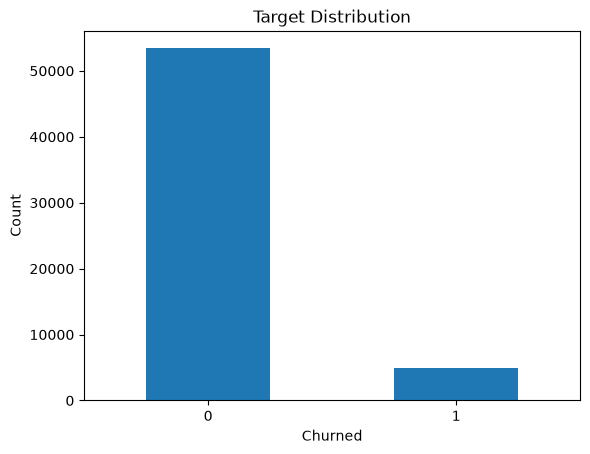

In [46]:
df["Churned"].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Churned")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### 4.4 Numerical distributions

Histograms help us see whether each numerical feature is:

- approximately symmetric
- right-skewed
- left-skewed
- affected by long tails

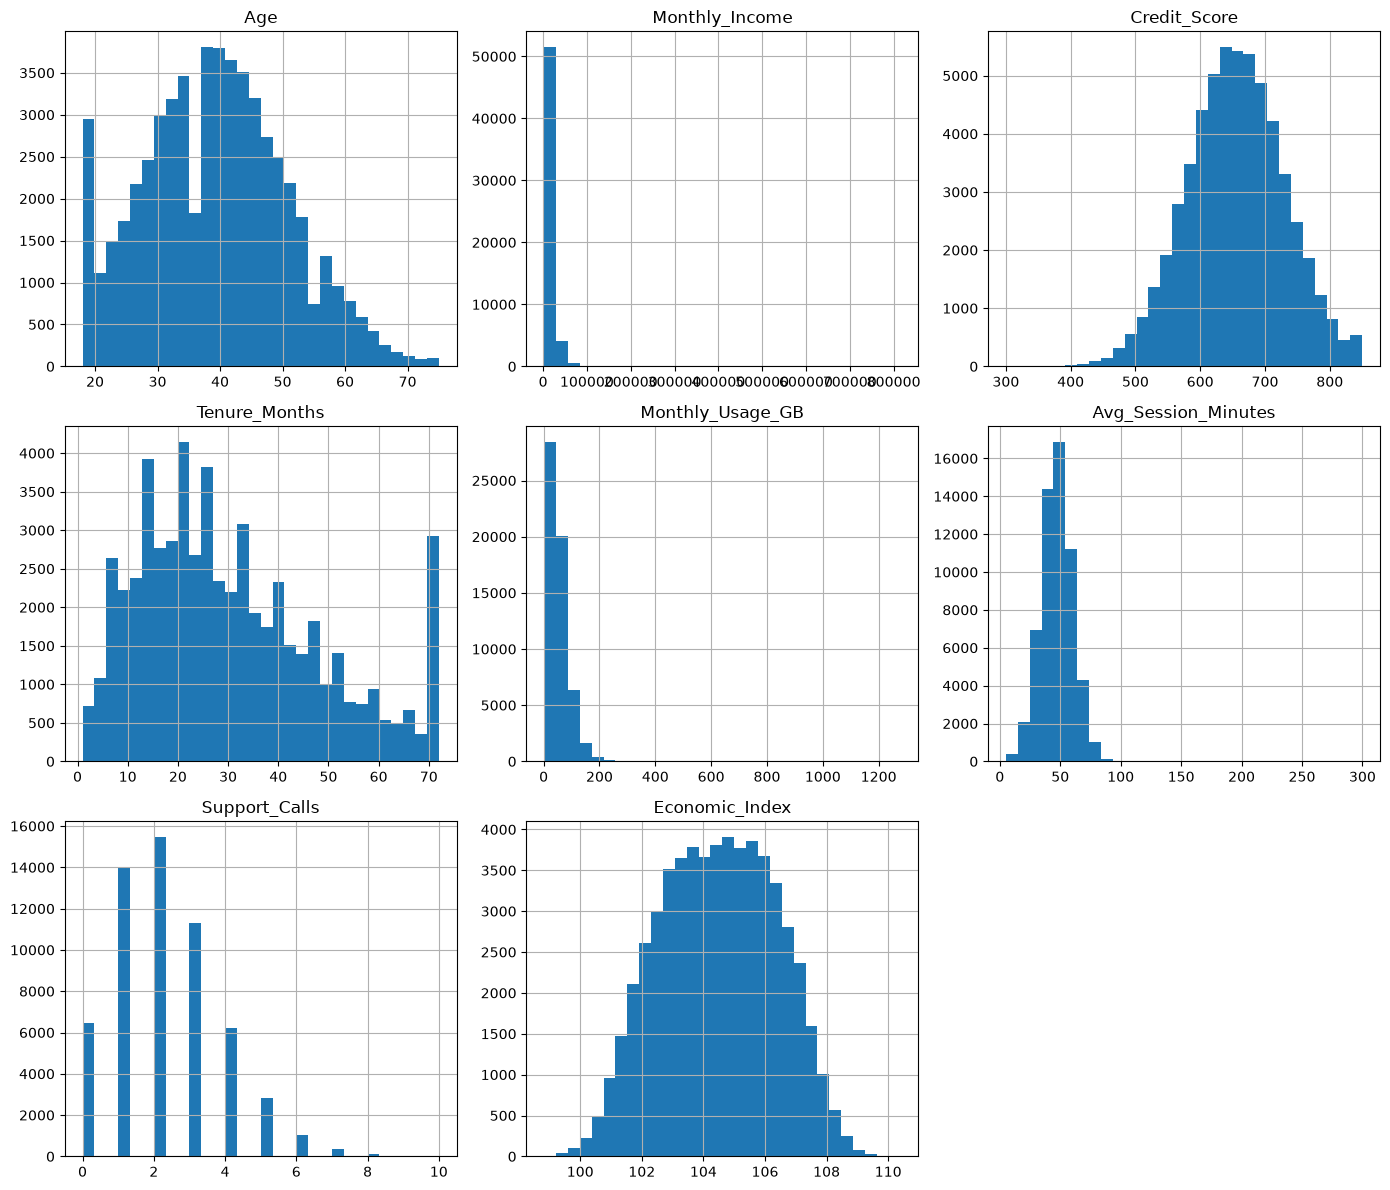

In [48]:
numeric_cols = df.select_dtypes(include="number").columns

numeric_cols = numeric_cols.drop(["Customer_ID", "Churned"], errors="ignore")

df[numeric_cols].hist(figsize=(14, 12), bins=30)

plt.tight_layout()
plt.show()

### 4.5 Skewness check

Skewness gives a numerical clue about distribution shape.

We still combine this with the plots and domain meaning.

In [50]:
df[numeric_cols].skew().round(3).sort_values(key=abs, ascending=False)
# sort for most skewd to less one
# near tan 0 will be symmetrc
# from 0.5 to 1 or from -0.5 to -1 will be moderate skew
# more than 1 or less than -1 will be strong skeew

Monthly_Income         11.241
Avg_Session_Minutes     4.284
Monthly_Usage_GB        3.881
Support_Calls           0.680
Tenure_Months           0.677
Age                     0.191
Economic_Index         -0.038
Credit_Score           -0.028
dtype: float64

### 4.6 Boxplots for possible outliers

Boxplots **flag candidates**.

They do not tell us that every flagged value should be removed.

In [52]:
import seaborn as sns

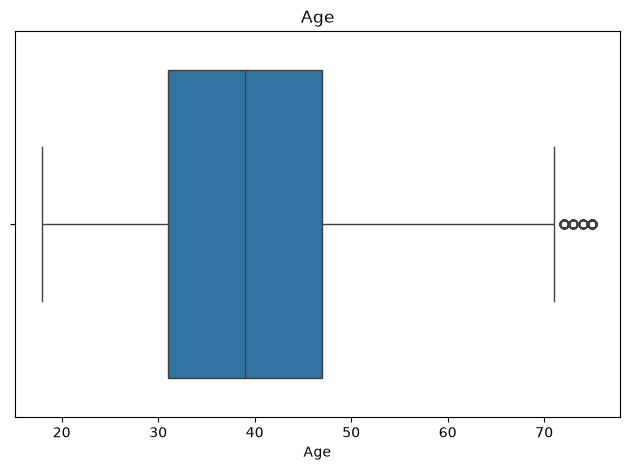

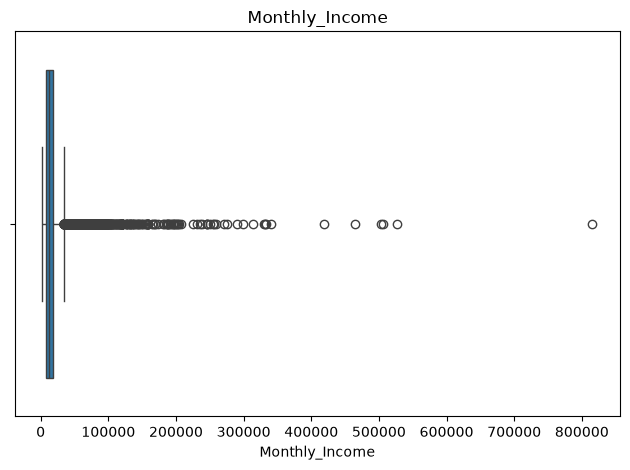

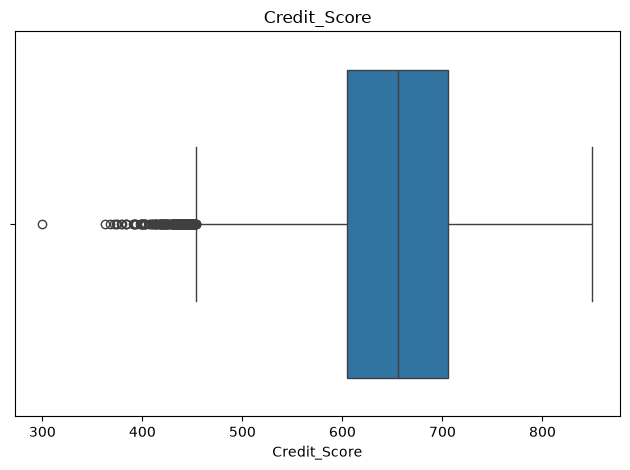

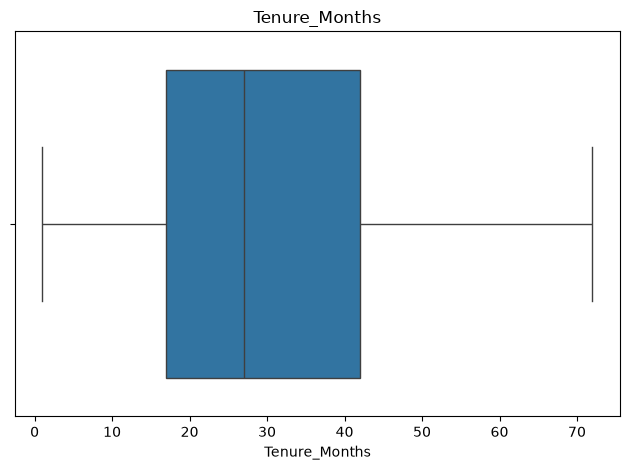

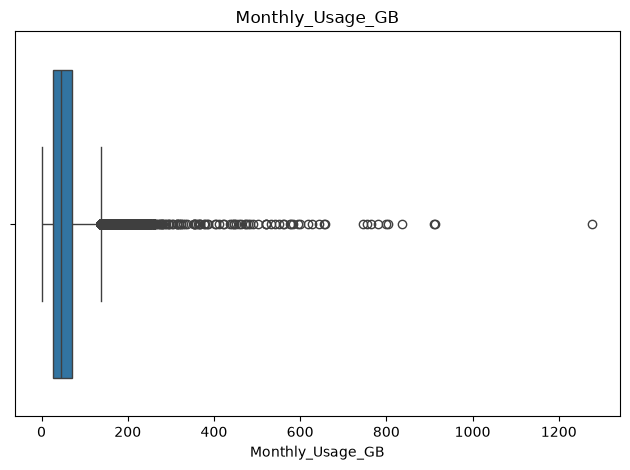

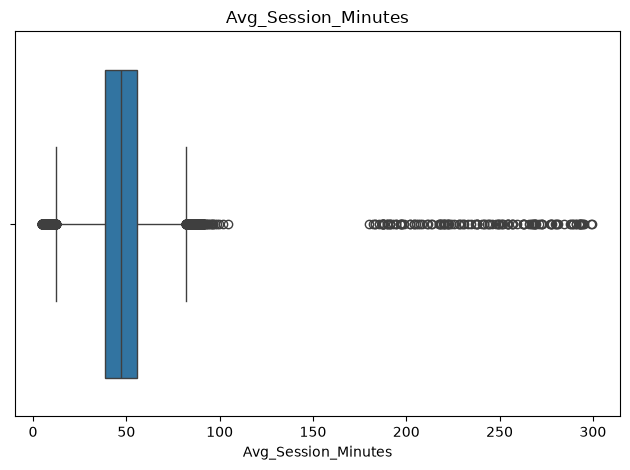

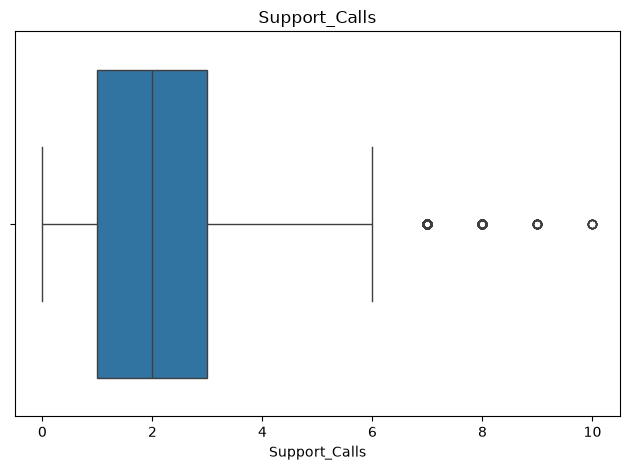

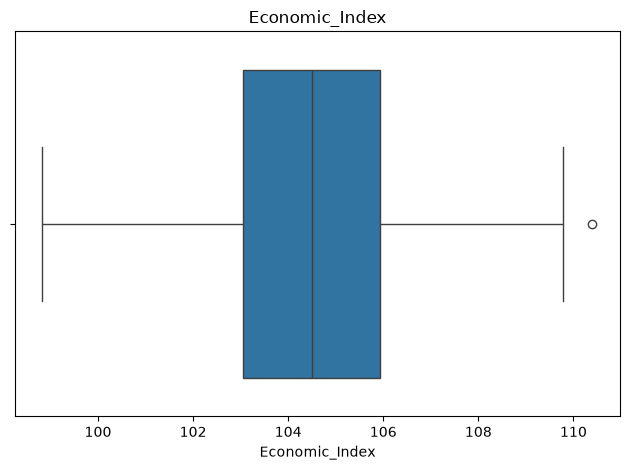

In [53]:
for col in numeric_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.tight_layout()
    plt.show()




### 4.7 Categorical distributions

We use `select_dtypes(include="object")` to identify the remaining object columns.

This helps us inspect:

- common categories
- rare categories
- missing categories
- whether One-Hot Encoding will be manageable

In [54]:
categorical_cols_eda = df.select_dtypes(include="object").columns.tolist()

print("Categorical columns:")
print(categorical_cols_eda)

for col in categorical_cols_eda:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


Categorical columns:
['City', 'Gender', 'Contract_Type', 'Satisfaction_Level', 'Promo_Code']

 City
City
cairo         24013
giza          11261
alexandria    10469
mansoura       6825
aswan          4592
NaN            1166
Name: count, dtype: int64

 Gender
Gender
male      30107
female    27515
NaN         704
Name: count, dtype: int64

 Contract_Type
Contract_Type
month-to-month    33273
one year          14292
two year           9713
NaN                1048
Name: count, dtype: int64

 Satisfaction_Level
Satisfaction_Level
medium    25808
high      17120
low       14228
NaN        1170
Name: count, dtype: int64

 Promo_Code
Promo_Code
NaN    52498
P20     1979
P10     1933
VIP     1916
Name: count, dtype: int64


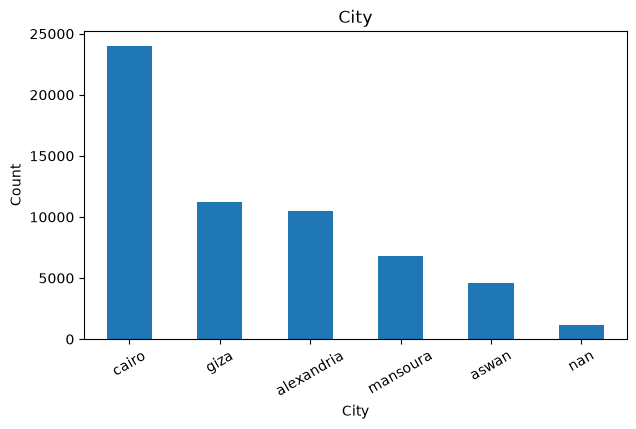

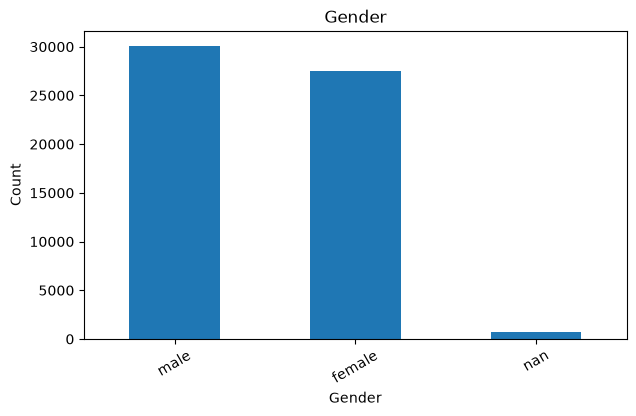

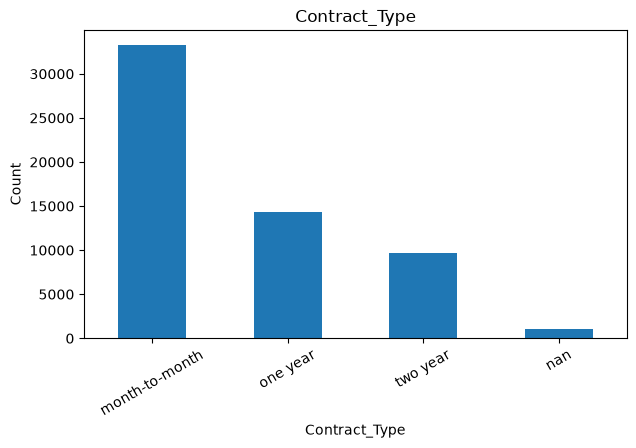

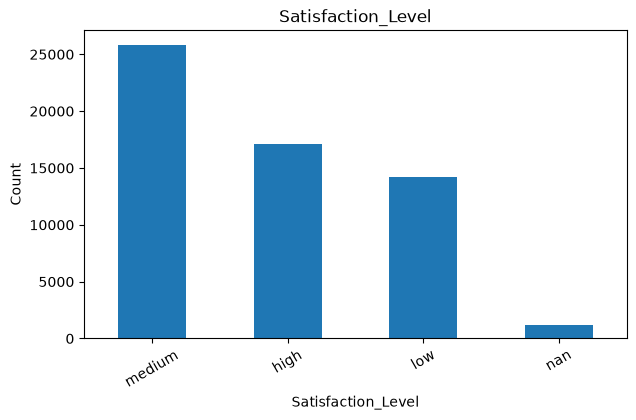

In [55]:
categorical_plot_cols = ["City", "Gender", "Contract_Type", "Satisfaction_Level"]

for col in categorical_plot_cols:
    df[col].value_counts(dropna=False).plot(kind="bar", figsize=(7, 4))
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()


### 4.8 Correlation between numerical features

Correlation helps us see which numerical variables move together.

We use it for understanding only. We are **not doing feature selection** in this session.

In [26]:
corr_cols = numeric_cols + ["Churned"]

corr = df[corr_cols].corr().round(2)
corr


,Age,Monthly_Income,Credit_Score,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Economic_Index,Churned
Age,1.00,-0.00,-0.0,0.00,0.00,0.00,-0.01,-0.0,-0.02
Monthly_Income,-0.00,1.00,0.0,0.00,-0.00,0.00,0.00,0.0,-0.01
Credit_Score,-0.00,0.00,1.0,0.00,0.00,-0.00,-0.00,0.0,0.00
Tenure_Months,0.00,0.00,0.0,1.00,0.00,0.00,0.00,-0.0,-0.03
Monthly_Usage_GB,0.00,-0.00,0.0,0.00,1.00,0.00,-0.00,0.0,0.02
Avg_Session_Minutes,0.00,0.00,-0.0,0.00,0.00,1.00,-0.01,0.0,-0.00
Support_Calls,-0.01,0.00,-0.0,0.00,-0.00,-0.01,1.00,0.0,0.04
Economic_Index,-0.00,0.00,0.0,-0.00,0.00,0.00,0.00,1.0,-0.00
Churned,-0.02,-0.01,0.0,-0.03,0.02,-0.00,0.04,-0.0,1.00


### 4.11 Datetime exploration

Datetime EDA helps us understand the period covered by the dataset and whether records change over time.

In [62]:
print("First date:", df["Application_Date"].min())
print("Last date :", df["Application_Date"].max())

First date: 2024-01-01 00:00:00
Last date : 2026-07-31 00:00:00


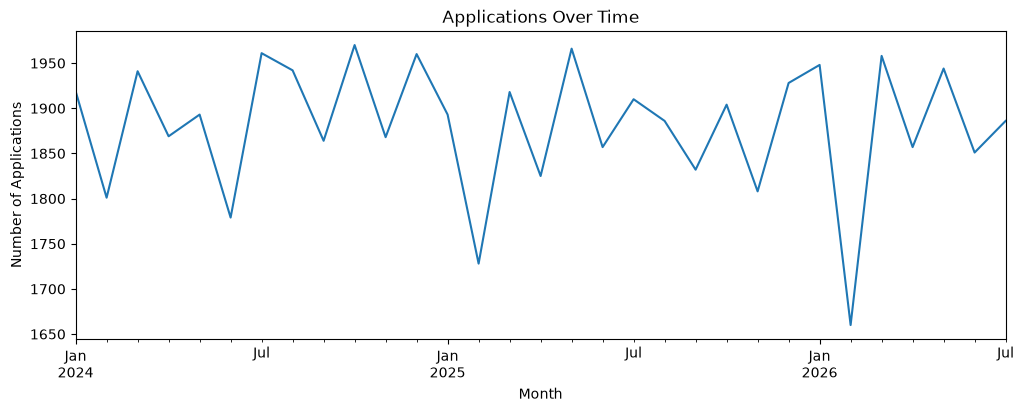

In [63]:
applications_by_month = df.groupby(
    df["Application_Date"].dt.to_period("M")
).size()

applications_by_month.plot(figsize=(12, 4))
plt.title("Applications Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Applications")
plt.show()


### EDA summary — what will guide later preprocessing?

The EDA gives us evidence for later choices:

- `Monthly_Income` is strongly right-skewed.
- `Monthly_Usage_GB` is strongly right-skewed.
- `Avg_Session_Minutes` is strongly right-skewed.
- `Age` is close to symmetric after invalid values are removed.
- `Credit_Score` is close to symmetric and already domain-bounded.
- `Economic_Index` is approximately symmetric.
- boxplots show possible outliers, but valid extremes must not be deleted blindly.
- categorical columns have manageable cardinality.
- the target is clearly imbalanced.
- datetime ordering exists and can be used for ordered missing data.

**Important:** these observations help us choose methods. Final statistics such as means, medians, IQR bounds, encoder categories, and scaler values will be learned from Training Data only.

# 5. Define X and y

`Churned` is the target.

`Customer_ID` is an identifier, so it is not used as a predictive feature.

In [21]:
X = df.drop(columns=["Churned", "Customer_ID"])
y = df["Churned"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (60000, 14)
y shape: (60000,)


# 6. Train / Test split

This is an imbalanced classification dataset.

`stratify=y` keeps approximately the same class ratio in Train and Test.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y # make sure the same percentage of random of split for xtrain an xtest to be the same ratio
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nTrain class %:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest class %:")
print((y_test.value_counts(normalize=True) * 100).round(2))


Train: (48000, 14)
Test : (12000, 14)

Train class %:
Churned
0    91.54
1     8.46
Name: proportion, dtype: float64

Test class %:
Churned
0    91.54
1     8.46
Name: proportion, dtype: float64


# From here: learn preprocessing rules from Training Data only

Training Data decides:

- imputation values
- outlier boundaries
- encoder categories
- scaling parameters
- resampling

Test Data receives the learned transformations and is never resampled.

# 7. Missing values — inspect Training Data first

Before filling anything, check the amount and type of missing data in Training Data.

In [66]:
X_train.head(5)

,Age,Monthly_Income,Credit_Score,City,Gender,Contract_Type,Satisfaction_Level,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Application_Date,Economic_Index,Promo_Code
14773,NaN,11912.06,601.6,mansoura,female,month-to-month,low,24.0,65.89,63.17,3.0,2024-10-16,102.29,NaN
42415,28.0,23186.01,695.1,cairo,male,month-to-month,high,28.0,20.08,36.01,2.0,2025-10-02,105.55,NaN
54029,51.0,6982.81,562.9,aswan,female,two year,low,53.0,32.95,37.00,4.0,2024-07-31,104.05,NaN
7577,33.0,15436.31,706.8,giza,male,month-to-month,high,61.0,90.87,44.13,2.0,2025-06-05,106.89,NaN
34052,40.0,30494.06,726.2,cairo,female,month-to-month,medium,11.0,73.11,54.06,6.0,2025-06-26,107.69,NaN


In [67]:
missing_train = X_train.isna().sum().to_frame("Missing_Count")

missing_train["Missing_%"] = (X_train.isna().mean() * 100).round(2)

missing_train["Data_Type"] = X_train.dtypes.astype(str)

missing_train.sort_values("Missing_%", ascending=False)


,Missing_Count,Missing_%,Data_Type
Promo_Code,42024,90.06,str
Age,1770,3.79,float64
Monthly_Income,1661,3.56,float64
Economic_Index,1310,2.81,float64
Credit_Score,1003,2.15,float64
Monthly_Usage_GB,958,2.05,float64
City,928,1.99,str
Satisfaction_Level,911,1.95,str
Contract_Type,810,1.74,str
Avg_Session_Minutes,704,1.51,float64


### Missing-value decisions for this dataset

| Column | Decision | Why |
|---|---|---|
| Promo_Code | Drop column | About 90% missing |
| Economic_Index | Ordered fill | Values change with datetime order |
| Age | Mean | Approximately symmetric |
| Credit_Score | Mean | Approximately symmetric and bounded |
| Monthly_Income | Median | Strong right skew |
| Monthly_Usage_GB | Median | Strong right skew |
| Avg_Session_Minutes | Median | Strong right skew |
| Tenure_Months | Median | Right-skewed |
| Support_Calls | Median | Discrete count with right tail |
| City | `unknown` | Avoid inventing a city |
| Gender | `unknown` | Avoid inventing a category |
| Contract_Type | Train mode | Reasonable classroom choice |
| Satisfaction_Level | Train mode | Reasonable classroom choice |

## 8. Drop the mostly-missing column

`Promo_Code` has very little usable information in this practice dataset.

In [31]:
X_train = X_train.drop(columns="Promo_Code")
X_test = X_test.drop(columns="Promo_Code")


In [32]:
X_train.head(3)

,Age,Monthly_Income,Credit_Score,City,Gender,Contract_Type,Satisfaction_Level,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Application_Date,Economic_Index
51959,35.0,17301.90,652.2,giza,female,month-to-month,medium,16.0,NaN,41.58,0.0,2024-01-17,103.02
51478,53.0,9151.84,606.2,cairo,male,month-to-month,high,72.0,74.45,41.50,1.0,2025-05-21,108.02
30851,41.0,16228.31,659.1,giza,female,month-to-month,high,38.0,119.57,11.02,0.0,2024-08-05,103.65


# 9. Ordered missing values with `ffill` and `bfill`

`Economic_Index` changes over time, so date order matters.

First, demonstrate what each method does:

- `ffill()` uses the previous known value.
- `bfill()` uses the next known value.

In real forecasting problems, `bfill()` can leak future information into the past.

For this classroom tabular example, the previous notebook demonstrated both methods inside each split. We keep that simple demonstration here, while remembering the leakage warning.

In [70]:
economic_example = X_train[ # we will make the bfill or ffill based on the app date
    ["Application_Date", "Economic_Index"]
].sort_values("Application_Date").head(12).copy()

economic_example["FFill"] = economic_example["Economic_Index"].ffill()
economic_example["BFill"] = economic_example["Economic_Index"].bfill()

economic_example


,Application_Date,Economic_Index,FFill,BFill
5439,2024-01-01,104.39,104.39,104.39
44419,2024-01-01,102.07,102.07,102.07
18158,2024-01-01,104.03,104.03,104.03
31879,2024-01-01,101.19,101.19,101.19
24388,2024-01-01,102.23,102.23,102.23
50102,2024-01-01,104.09,104.09,104.09
15162,2024-01-01,103.34,103.34,103.34
9303,2024-01-01,102.74,102.74,102.74
57720,2024-01-01,102.08,102.08,102.08
11877,2024-01-01,102.39,102.39,102.39


In [71]:
train_sorted = X_train.sort_values("Application_Date")
test_sorted = X_test.sort_values("Application_Date")

X_train["Economic_Index"] = train_sorted["Economic_Index"].ffill().bfill()
X_test["Economic_Index"] = test_sorted["Economic_Index"].ffill().bfill()

print("Train missing Economic_Index:", X_train["Economic_Index"].isna().sum())
print("Test missing Economic_Index :", X_test["Economic_Index"].isna().sum())


Train missing Economic_Index: 0
Test missing Economic_Index : 0


- 102
- 102
- 102
- 103
- 103 ---> forword fill
- 104

- by using .ffill()
- it will be by using both
- 102
- 102
- 102
- 103
- 130
- 104

# 10. Numerical missing values — choose from Training distributions

We calculate skewness from **Training Data**.

Simple classroom guide:

- approximately symmetric → Mean can be reasonable
- skewed / outlier-prone → Median is usually safer

In [72]:
numeric_for_missing = [
    "Age", "Monthly_Income", "Credit_Score", "Tenure_Months",
    "Monthly_Usage_GB", "Avg_Session_Minutes", "Support_Calls"
]

print("Missing values:")
print(X_train[numeric_for_missing].isna().sum())

print("\nSkewness:")
print(X_train[numeric_for_missing].skew().round(3))


Missing values:
Age                    1770
Monthly_Income         1661
Credit_Score           1003
Tenure_Months           674
Monthly_Usage_GB        958
Avg_Session_Minutes     704
Support_Calls           464
dtype: int64

Skewness:
Age                    0.194
Monthly_Income         9.337
Credit_Score          -0.027
Tenure_Months          0.675
Monthly_Usage_GB       3.784
Avg_Session_Minutes    4.284
Support_Calls          0.676
dtype: float64


In [33]:
# Mean for approximately symmetric columns
for col in ["Age", "Credit_Score"]:
    value = X_train[col].mean()
    X_train[col] = X_train[col].fillna(value)
    X_test[col] = X_test[col].fillna(value)
    print(col, "-> mean =", round(value, 2))

Age -> mean = 39.2
Credit_Score -> mean = 655.28


In [34]:
# Median for skewed or discrete columns
median_cols = [
    "Monthly_Income", "Tenure_Months", "Monthly_Usage_GB",
    "Avg_Session_Minutes", "Support_Calls"
]

for col in median_cols:
    value = X_train[col].median()
    X_train[col] = X_train[col].fillna(value)
    X_test[col] = X_test[col].fillna(value)
    print(col, "-> median =", round(value, 2))


Monthly_Income -> median = 11921.67
Tenure_Months -> median = 27.0
Monthly_Usage_GB -> median = 44.8
Avg_Session_Minutes -> median = 47.11
Support_Calls -> median = 2.0


# 11. Categorical missing values — inspect each feature

A missing category is not always handled in the same way.

We use `unknown` when guessing a person's category would create false information, and Train mode when it is acceptable for this teaching example.

In [75]:
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    print("\n", col)
    print(X_train[col].value_counts(dropna=False).head())


Categorical columns: ['City', 'Gender', 'Contract_Type', 'Satisfaction_Level']

 City
City
cairo         19277
giza           8961
alexandria     8392
mansoura       5445
aswan          3657
Name: count, dtype: int64

 Gender
Gender
male      24129
female    21969
NaN         562
Name: count, dtype: int64

 Contract_Type
Contract_Type
month-to-month    26620
one year          11507
two year           7723
NaN                 810
Name: count, dtype: int64

 Satisfaction_Level
Satisfaction_Level
medium    20675
high      13720
low       11354
NaN         911
Name: count, dtype: int64


In [35]:
# Keep missing values as "unknown"
X_train["City"] = X_train["City"].fillna("unknown")
X_test["City"] = X_test["City"].fillna("unknown")

In [36]:
X_train["Gender"] = X_train["Gender"].fillna("unknown")
X_test["Gender"] = X_test["Gender"].fillna("unknown")


In [78]:
# Use Train mode for these two columns
for col in ["Contract_Type", "Satisfaction_Level"]:
    value = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(value)
    X_test[col] = X_test[col].fillna(value)
    print(col, "-> mode =", value)


Contract_Type -> mode = month-to-month
Satisfaction_Level -> mode = medium


# 12. Outliers — diagnose every numerical feature

For each numerical feature, inspect:

- skewness
- IQR outlier count
- Z-score `|Z| > 3` count
- minimum
- maximum

Then choose a treatment **column by column**.

In [ ]:
numeric_check_cols = [
    "Age", "Monthly_Income", "Credit_Score", "Tenure_Months",
    "Monthly_Usage_GB", "Avg_Session_Minutes", "Support_Calls",
    "Economic_Index"
]

for col in numeric_check_cols:
    data = X_train[col]

    q1 = data.quantile(0.25) #25%
    q3 = data.quantile(0.75) #75%
    iqr = q3 - q1 #50%
    lower = q1 - 1.5 * iqr  
    upper = q3 + 1.5 * iqr 
    iqr_outliers = ((data < lower) | (data > upper)).sum()
    #--------------------------------------------------------------
    z = ((data - data.mean()) / data.std()).abs() # x-mean/std
    z_outliers = (z > 3).sum()

    print("\n", col)
    print("Skewness:", round(data.skew(), 3))
    print("IQR outliers:", iqr_outliers)
    print("Z > 3:", z_outliers)
    print("Min:", round(data.min(), 2))
    print("Max:", round(data.max(), 2))



 Age
Skewness: 0.198
IQR outliers: 148
Z > 3: 76
Min: 18.0
Max: 75.0

 Monthly_Income
Skewness: 9.505
IQR outliers: 2617
Z > 3: 542
Min: 2500.0
Max: 526856.44

 Credit_Score
Skewness: -0.028
IQR outliers: 187
Z > 3: 59
Min: 300.0
Max: 850.0

 Tenure_Months
Skewness: 0.688
IQR outliers: 0
Z > 3: 0
Min: 1.0
Max: 72.0



 Monthly_Usage_GB
Skewness: 3.831
IQR outliers: 1519
Z > 3: 517
Min: 2.0
Max: 1278.22

 Avg_Session_Minutes
Skewness: 4.317
IQR outliers: 527
Z > 3: 115
Min: 5.0
Max: 299.8

 Support_Calls
Skewness: 0.683
IQR outliers: 352
Z > 3: 352
Min: 0.0
Max: 10.0

 Economic_Index
Skewness: -0.037
IQR outliers: 1
Z > 3: 2
Min: 98.83
Max: 110.4


### Outlier decision for each numerical column

| Column | Decision | Reason |
|---|---|---|
| Age | Keep | Remaining values are valid ages; IQR flags do not automatically mean errors |
| Monthly_Income | IQR capping | Strong right skew and many extreme values |
| Credit_Score | Keep | Already domain-bounded; valid extremes can remain |
| Tenure_Months | Keep | No meaningful extreme problem |
| Monthly_Usage_GB | IQR capping | Strong right skew |
| Avg_Session_Minutes | IQR capping | Strong right skew |
| Support_Calls | Keep | Valid discrete count data |
| Economic_Index | Z-score capping | Approximately symmetric |

We use capping instead of deleting customer rows.

## 13. IQR handling for strongly skewed columns

IQR is a good fit here because quartiles are more resistant to extreme magnitudes.

Learn the boundaries from Train and apply the same boundaries to Test.

- Q1 = 10
- Q3 = 20
- IQR = 20 - 10 = 10

- Lower = 10 - (1.5 × 10) = -5 # lower 
- Upper = 20 + (1.5 × 10) = 35 # highest

In [79]:
iqr_cols = ["Monthly_Income", "Monthly_Usage_GB", "Avg_Session_Minutes"]

for col in iqr_cols:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1 # 50%

    lower = q1 - 1.5 * iqr # -4 
    upper = q3 + 1.5 * iqr # 500

    print(col, "limits:", round(lower, 2), "to", round(upper, 2))

    X_train[col] = X_train[col].clip(lower, upper) # any value less than lower value make it lower
    X_test[col] = X_test[col].clip(lower, upper) # any value gretaer than upper value mke it upper


Monthly_Income limits: -7835.92 to 33999.03
Monthly_Usage_GB limits: -37.89 to 134.6
Avg_Session_Minutes limits: 12.92 to 81.24


# 14. Z-score handling for an approximately symmetric feature

Z-score measures distance from the mean in standard deviations.

`Economic_Index` is close to symmetric, so mean and standard deviation are meaningful enough for this example.

In [80]:
mean = X_train["Economic_Index"].mean()
std = X_train["Economic_Index"].std()

z = ((X_train["Economic_Index"] - mean) / std).abs()
print("Economic_Index values with |Z| > 3:", (z > 3).sum())

lower = mean - 3 * std
upper = mean + 3 * std

X_train["Economic_Index"] = X_train["Economic_Index"].clip(lower, upper)
X_test["Economic_Index"] = X_test["Economic_Index"].clip(lower, upper)

print("Z-score limits:", round(lower, 2), "to", round(upper, 2))


Economic_Index values with |Z| > 3: 2
Z-score limits: 98.85 to 110.11


## Check distributions after outlier handling

Only the columns that needed treatment were capped.

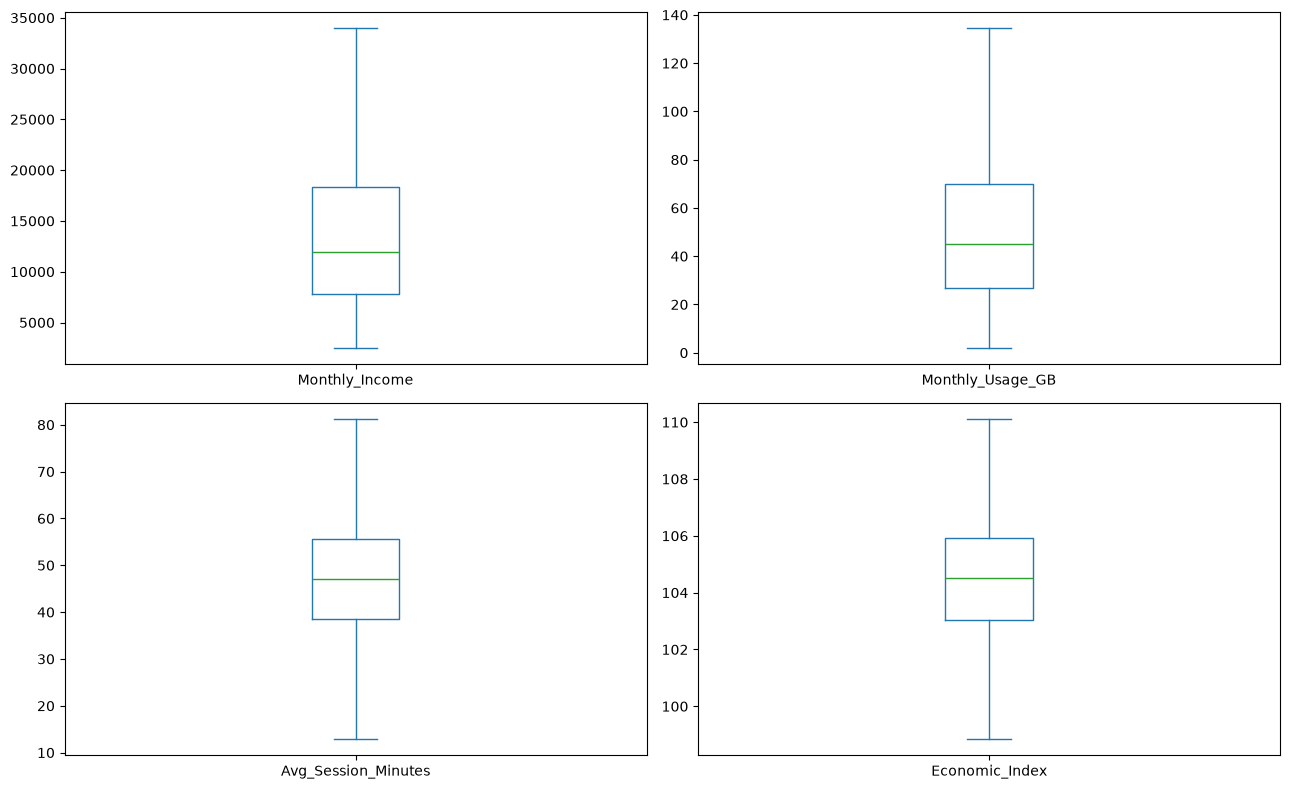

In [81]:
check_cols = [
    "Monthly_Income", "Monthly_Usage_GB",
    "Avg_Session_Minutes", "Economic_Index"
]

X_train[check_cols].plot(
    kind="box",
    subplots=True,
    layout=(2, 2),
    figsize=(13, 8)
)

plt.tight_layout()
plt.show()


# 16. Encoding — choose by category type

| Column | Type | Encoding |
|---|---|---|
| Satisfaction_Level | Ordinal | Ordered mapping |
| City | Nominal | One-Hot Encoding |
| Gender | Nominal | One-Hot Encoding |
| Contract_Type | Nominal | One-Hot Encoding |

Nominal categories do not have a meaningful ranking.

In [82]:
X_train.head(2)

,Age,Monthly_Income,Credit_Score,City,Gender,Contract_Type,Satisfaction_Level,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Application_Date,Economic_Index
14773,39.18376,11912.06,601.6,mansoura,female,month-to-month,low,24.0,65.89,63.17,3.0,2024-10-16,102.29
42415,28.00000,23186.01,695.1,cairo,male,month-to-month,high,28.0,20.08,36.01,2.0,2025-10-02,105.55


In [37]:
satisfaction_order = {
    "low": 0,
    "medium": 1,
    "high": 2
}

X_train["Satisfaction_Level"] = X_train["Satisfaction_Level"].map(satisfaction_order)
X_test["Satisfaction_Level"] = X_test["Satisfaction_Level"].map(satisfaction_order)

X_train["Satisfaction_Level"].value_counts().sort_index()


Satisfaction_Level
0.0    11577
1.0    21234
2.0    14034
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False, 

).set_output(transform="pandas")


encoder.fit_transform(X_train)
encoder.transform(X_test) 

In [84]:
nominal_cols = ["City", "Gender", "Contract_Type"]

encoder = OneHotEncoder(
    handle_unknown="ignore", # if in test there is a new category do not appear an error
    sparse_output=False #return back the result to a normal array not zero matrix
).set_output(transform="pandas") # to return the column with the encoding with the new name

train_encoded = encoder.fit_transform(X_train[nominal_cols])
test_encoded = encoder.transform(X_test[nominal_cols])

X_train = pd.concat( #remove older columns and add new columns by one hot encoding
    [X_train.drop(columns=nominal_cols), train_encoded],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(columns=nominal_cols), test_encoded],
    axis=1
)

print("Encoded columns:")
print(train_encoded.columns.tolist())


Encoded columns:
['City_alexandria', 'City_aswan', 'City_cairo', 'City_giza', 'City_mansoura', 'City_unknown', 'Gender_female', 'Gender_male', 'Gender_unknown', 'Contract_Type_month-to-month', 'Contract_Type_one year', 'Contract_Type_two year']


# 17. Feature scaling — choose by feature behavior

### RobustScaler

Use for the continuous columns that were strongly skewed / outlier-prone:

- Monthly_Income
- Monthly_Usage_GB
- Avg_Session_Minutes

### StandardScaler

Use for ordinary bounded or approximately symmetric numerical features:

- Age
- Credit_Score
- Tenure_Months
- Support_Calls
- Economic_Index
- extracted calendar features

Fit each scaler on Train only.

In [ ]:
robust_cols = [
    "Monthly_Income", "Monthly_Usage_GB", "Avg_Session_Minutes"
]

standard_cols = [
    "Age", "Credit_Score", "Tenure_Months", "Support_Calls",
    "Economic_Index"
]

robust_scaler = RobustScaler()
X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols] = robust_scaler.transform(X_test[robust_cols])

standard_scaler = StandardScaler()
X_train[standard_cols] = standard_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols] = standard_scaler.transform(X_test[standard_cols])



In [88]:
X_train.head(2)

,Age,Monthly_Income,Credit_Score,Satisfaction_Level,Tenure_Months,Monthly_Usage_GB,Avg_Session_Minutes,Support_Calls,Application_Date,Economic_Index,City_alexandria,City_aswan,City_cairo,City_giza,City_mansoura,City_unknown,Gender_female,Gender_male,Gender_unknown,Contract_Type_month-to-month,Contract_Type_one year,Contract_Type_two year
14773,-1.917217e-16,-0.002415,-0.729815,0,-0.366662,0.487680,0.940281,0.535289,2024-10-16,-1.167593,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
42415,-9.869236e-01,1.075530,0.535023,2,-0.144142,-0.574642,-0.649883,-0.137264,2025-10-02,0.569350,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


# 18. Final preprocessing checks before balancing

At this point:

- features should be numerical
- missing values should be gone
- Test has not been resampled

In [89]:
print("Train missing values:", X_train.isna().sum().sum())
print("Test missing values :", X_test.isna().sum().sum())

print("\nTrain non-numeric columns:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train missing values: 0
Test missing values : 0

Train non-numeric columns:
['Application_Date']

Train shape: (46660, 22)
Test shape : (11666, 22)


# 19. Handle class imbalance — compare three methods

We compare three **alternative Training Sets**:

1. Random Oversampling
2. Random Undersampling
3. SMOTE

Test Data remains unchanged.

No model is trained yet.

In [38]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [90]:
print("Original Training distribution:")
print(y_train.value_counts())

print("\nPercent:")
print((y_train.value_counts(normalize=True) * 100).round(2))


Original Training distribution:
Churned
0    42712
1     3948
Name: count, dtype: int64

Percent:
Churned
0    91.54
1     8.46
Name: proportion, dtype: float64


## 19.1 Random Oversampling

Repeat minority observations until the classes are balanced.

**Advantage:** keeps all majority observations.

**Risk:** repeated minority rows can contribute to overfitting later.

In [91]:
ros = RandomOverSampler(random_state=42)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("Shape:", X_train_over.shape)
print(y_train_over.value_counts())


Shape: (85424, 22)
Churned
0    42712
1    42712
Name: count, dtype: int64


## 19.2 Random Undersampling

Remove majority observations until the classes are balanced.

**Advantage:** smaller and faster dataset.

**Risk:** useful majority information can be lost.

In [92]:
rus = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Shape:", X_train_under.shape)
print(y_train_under.value_counts())


Shape: (7896, 22)
Churned
0    3948
1    3948
Name: count, dtype: int64


## 19.3 SMOTE

SMOTE creates synthetic minority observations between nearby minority points.

Because it uses distance, it is shown after encoding and scaling.

For mixed datasets with true categorical features, `SMOTENC` may be more suitable.

In [94]:
X_train = X_train.drop(columns=["Application_Date"])
X_test = X_test.drop(columns=["Application_Date"])

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Shape:", X_train_smote.shape)
print(y_train_smote.value_counts())

Shape: (85424, 21)
Churned
0    42712
1    42712
Name: count, dtype: int64


## Compare the original and balanced Training Sets

We do not choose a winner because model training belongs to a later session.

In [95]:
balance_comparison = pd.DataFrame({
    "Original": y_train.value_counts(),
    "Random_Over": y_train_over.value_counts(),
    "Random_Under": y_train_under.value_counts(),
    "SMOTE": y_train_smote.value_counts()
})

balance_comparison


,Original,Random_Over,Random_Under,SMOTE
Churned,,,,
0,42712,42712,3948,42712
1,3948,42712,3948,42712


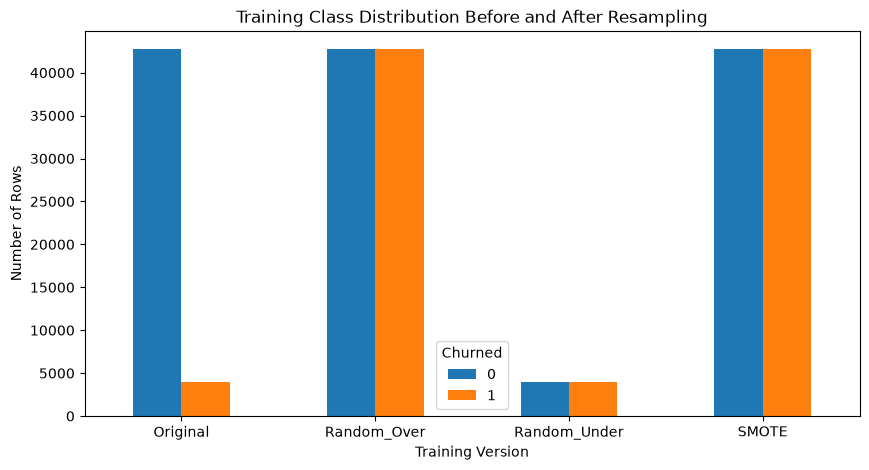

In [96]:
balance_comparison.T.plot(kind="bar", figsize=(10, 5))
plt.title("Training Class Distribution Before and After Resampling")
plt.xlabel("Training Version")
plt.ylabel("Number of Rows")
plt.xticks(rotation=0)
plt.show()


# 20. Save model-ready Train and Test data

We save the preprocessed data **before choosing a resampling method**.

Oversampling, undersampling, and SMOTE remain alternative Training Sets for the future modeling session.

In [97]:
train_ready = X_train.copy()
train_ready["Churned"] = y_train

test_ready = X_test.copy()
test_ready["Churned"] = y_test

train_ready.to_csv("customer_churn_preprocessed_train.csv", index=False)
test_ready.to_csv("customer_churn_preprocessed_test.csv", index=False)

print("Saved train:", train_ready.shape)
print("Saved test :", test_ready.shape)


Saved train: (46660, 22)
Saved test : (11666, 22)


# Final preprocessing order

1. Import the raw dataset.
2. Inspect `head`, shape, `info`, numerical `describe`, and object columns with `select_dtypes`.
3. Inspect raw missing values, duplicates, and target distribution.
4. Apply deterministic basic cleaning.
5. Convert datetime correctly.
6. Perform fuller EDA:
   - missingness
   - target distribution
   - numerical distributions
   - skewness
   - boxplots
   - categorical distributions
   - correlation
   - numerical features vs target
   - categorical features vs target
   - datetime exploration
7. Define `X` and `y`.
8. Split Train/Test with stratification.
9. Learn missing-value rules from Train.
10. Handle ordered missing data.
11. Handle numerical and categorical missing values column by column.
12. Diagnose outliers for every numerical feature.
13. Apply IQR only where it fits.
14. Apply Z-score where approximately symmetric data supports it.
15. Extract simple datetime features.
16. Encode ordinal and nominal categories differently.
17. Scale feature groups appropriately.
18. Check the final feature matrix.
19. Compare Random Oversampling, Random Undersampling, and SMOTE on Train only.
20. Stop at model-ready data.

**Core rule:** detect and understand early; learn preprocessing parameters from Training Data only.